# Assignment-4 COMP-5970 Jacob Murrah
## README
Design a small CNN from scratch (5–10 layers), train it on CIFAR-10, then
upgrade it with residual connections and compare. Finally, pretrain one of
your models with a self-supervised objective and fine-tune on labels. You’ll
analyze accuracy, data efficiency, convergence, and learned features.

## Dependencies
- **Python 3.x**
- **numpy**
- **matplotlib**
- **pytorch**
- **tensorflow**
- **scikit learn**
- **seaborn**

*Note: If you are running this notebook in Google Colab, all the required packages are pre-installed.*

## Instructions
1. **Run All Cells:** Please click on \"Runtime\" > \"Run all\" to execute the entire notebook sequentially.
2. **Review the Outputs:** The notebook is organized into several sections. Ensure that all cells run without errors.

## GenAI Usage Declaration
a

## Statement of Contribution
This was an individual project and I did everything in it.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
import tensorflow as tf
import torchvision, torchvision.transforms as transforms
from torch.utils.data import Subset
from collections import defaultdict
from sklearn.metrics import confusion_matrix
import seaborn as sns

2025-11-23 21:35:44.940414: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-23 21:35:44.978169: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-23 21:35:45.680980: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
# Load CIFAR-10 dataset
CIFAR_CLASSES = [
    'plane',
    'car',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([
        transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)
    ]),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2023, 0.1994, 0.2010]
    )
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2023, 0.1994, 0.2010]
    )
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, transform=train_transform, download=True
)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, transform=test_transform, download=True
)

train_loader = torch.utils.data.DataLoader(
    dataset=train_dataset, batch_size=96, num_workers=2, shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset, batch_size=96, shuffle=True
)

In [4]:
class EncoderWrapper(nn.Module):
    def __init__(
        self,
        encoder,
        latent_dim=128,
        output_dim=10
    ):
        super().__init__()
        self.encoder = encoder

        self.head = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim)
        )

    def forward(self, x):
        features = self.encoder(x)
        return self.head(features)

def train_epoch(m, criterion, opt, loader):
    m.train()
    total, correct, loss_sum = 0, 0, 0.0
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        opt.zero_grad()

        logits = m(images)
        loss = criterion(logits, labels)

        loss.backward()
        opt.step()

        pred = torch.argmax(logits, dim=1)
        correct += (pred == labels).sum().item()
        loss_sum += loss.item() * labels.size(0)

        total += labels.size(0)

    return loss_sum / total, correct / total

def test_epoch(m, criterion):
    m.eval()
    total, correct, loss_sum = 0, 0, 0.0
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = m(images)
            loss = criterion(logits, labels)

            pred = torch.argmax(logits, dim=1)
            correct += (pred == labels).sum().item()
            loss_sum += loss.item() * labels.size(0)

            total += labels.size(0)

    return loss_sum / total, correct / total

def train_model(m, c, o, l):
    history = defaultdict(list)
    for epoch in range(30):
        tr_loss, tr_acc = train_epoch(m, c, o, l)
        te_loss, te_acc = test_epoch(m, c)

        print(
            "ep%d: tr_loss: %.3f, tr_acc: %.3f | te_loss: %.3f, te_acc: %.3f" % (
                epoch, tr_loss, tr_acc, te_loss, te_acc
            )
        )

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['test_loss'].append(te_loss)
        history['test_acc'].append(te_acc)

    return history

# Task 1) Small CNN (from scratch)
Implement and train a compact CNN classifier on CIFAR-10 with the
following specifications:
- 5–10 learnable layers (conv/normalization/activation/linear count
toward depth; pooling doesn’t).
- ≤ 1.5M parameters (show a param count).
- Use standard training (cross-entropy) and reasonable augments
(random crop/flip, optional color jitter).
- Train to reasonable test accuracy (don’t overtrain; ~20–30 epochs or
early stopping is fine).

## Description of Approach
a

In [5]:
class SimpleCNNEncoder(nn.Module):
    def __init__(self, in_channels=3, latent_ch=128):
        super().__init__()
        self.dropout = nn.Dropout(0.5)

        self.conv1 = nn.Conv2d(
            in_channels=in_channels,
            out_channels=64,
            kernel_size=3,
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(64)
        self.relu1 = nn.ReLU(inplace=True)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(
            in_channels=64,
            out_channels=128,
            kernel_size=3,
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(128)
        self.relu2 = nn.ReLU(inplace=True)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(
            in_channels=128,
            out_channels=256,
            kernel_size=3,
            padding=1,
            bias=False
        )
        self.bn3 = nn.BatchNorm2d(256)
        self.relu3 = nn.ReLU(inplace=True)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc = nn.Linear(
            in_features=256 * 4 * 4, out_features=latent_ch
        )

    def forward(self, x):
        x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu2(self.bn2(self.conv2(x))))
        x = self.pool3(self.relu3(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

In [6]:
model1 = EncoderWrapper(encoder=SimpleCNNEncoder()).to(device)
opt1 = torch.optim.SGD(
    model1.parameters(), lr=0.001, weight_decay=1e-4, momentum=0.9
)
criterion1 = nn.CrossEntropyLoss()

print("--- Training SimpleCNNEncoder Model ---")
history1 = train_model(model1, criterion1, opt1, train_loader)

--- Training SimpleCNNEncoder Model ---
ep0: tr_loss: 1.820, tr_acc: 0.332 | te_loss: 1.413, te_acc: 0.488
ep1: tr_loss: 1.474, tr_acc: 0.461 | te_loss: 1.215, te_acc: 0.564
ep2: tr_loss: 1.328, tr_acc: 0.521 | te_loss: 1.137, te_acc: 0.592
ep3: tr_loss: 1.227, tr_acc: 0.561 | te_loss: 1.017, te_acc: 0.641
ep4: tr_loss: 1.165, tr_acc: 0.585 | te_loss: 0.987, te_acc: 0.646
ep5: tr_loss: 1.113, tr_acc: 0.604 | te_loss: 0.937, te_acc: 0.668
ep6: tr_loss: 1.064, tr_acc: 0.621 | te_loss: 0.877, te_acc: 0.688
ep7: tr_loss: 1.029, tr_acc: 0.636 | te_loss: 0.925, te_acc: 0.676
ep8: tr_loss: 1.003, tr_acc: 0.647 | te_loss: 0.822, te_acc: 0.717
ep9: tr_loss: 0.972, tr_acc: 0.658 | te_loss: 0.823, te_acc: 0.709
ep10: tr_loss: 0.953, tr_acc: 0.662 | te_loss: 0.777, te_acc: 0.732
ep11: tr_loss: 0.932, tr_acc: 0.671 | te_loss: 0.758, te_acc: 0.736
ep12: tr_loss: 0.920, tr_acc: 0.675 | te_loss: 0.769, te_acc: 0.738
ep13: tr_loss: 0.897, tr_acc: 0.683 | te_loss: 0.746, te_acc: 0.737
ep14: tr_loss: 0.8

Task 1 Part a) **Model diagram**
![](task1diagram.png)

My SimpleCNNEncoder extracts the features of the input 32x32x3 RGB image and outputs a 128 latent vector. The EncoderWrapper class acts as the classifier head and takes the 128 dimension latent vector and outputs the 10 output logits that represent the CIFAR10 classes.

Total Parameters: 904586


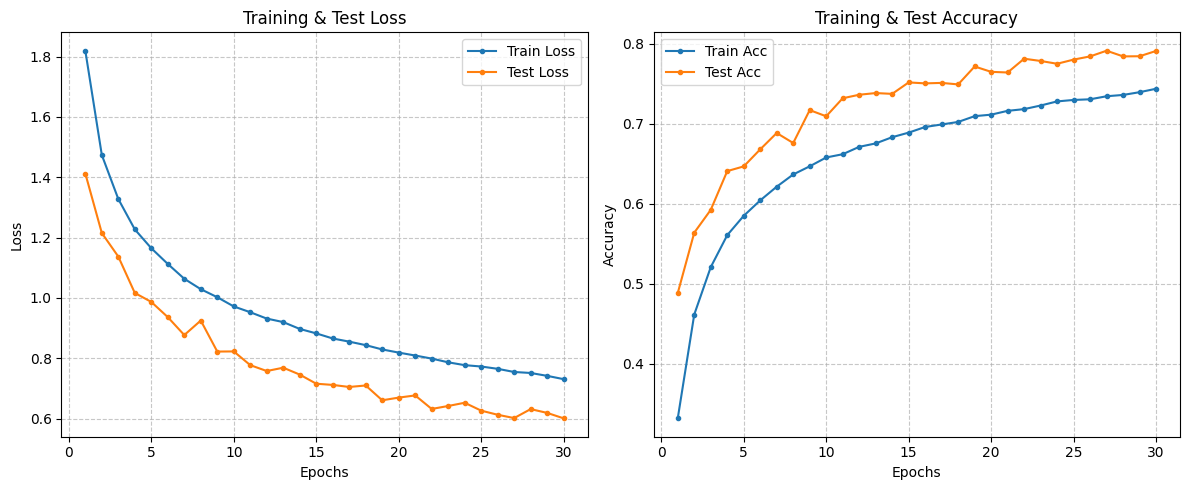

In [7]:
# param count
param_count = sum(p.numel() for p in model1.parameters())
print(f"Total Parameters: {param_count}")

# plot training curves
epochs = range(1, len(history1['train_loss']) + 1)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, history1['train_loss'], label='Train Loss', marker='.')
plt.plot(epochs, history1['test_loss'], label='Test Loss', marker='.')
plt.title('Training & Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
plt.plot(epochs, history1['train_acc'], label='Train Acc', marker='.')
plt.plot(epochs, history1['test_acc'], label='Test Acc', marker='.')
plt.title('Training & Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Final Accuracy:  0.7907


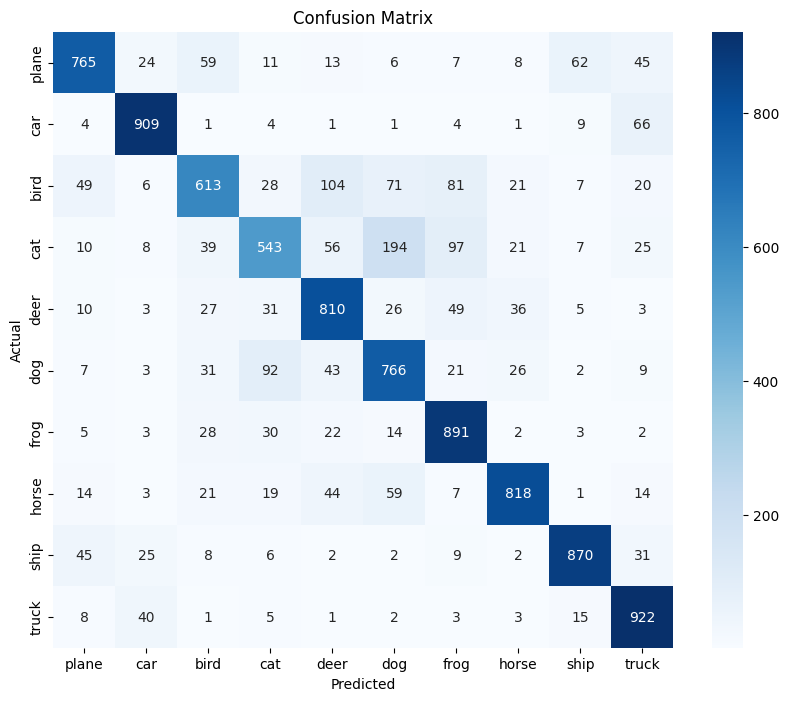

In [8]:
# final test accuracy & confusion matrix
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model1(images)
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

final_acc = np.mean(np.array(all_preds) == np.array(all_labels))
print("Final Accuracy: ", final_acc)

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CIFAR_CLASSES,
    yticklabels=CIFAR_CLASSES
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Task 2) Improve your CNN
Modify your CNN to include identity (skip) connections where shapes
match (e.g., two convs per block), and projection when they don’t (1×1 conv).
Make sure to follow the below specifications:
- Keep overall depth and parameter budget comparable (±20% is fine).
- Reuse the same optimizer/augments unless you justify changes.
- Train and compare against Part A.

## Description of Approach
a

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv = nn.Conv2d(
            in_channels, out_channels, kernel_size=3, padding=1, bias=False
        )
        self.bn = nn.BatchNorm2d(out_channels)

        if in_channels != out_channels:
            self.proj = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
            self.proj_bn = nn.BatchNorm2d(out_channels)
        else:
            self.proj = None

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        identity = x

        out = self.conv(x)
        out = self.bn(out)

        if self.proj is not None:
            identity = self.proj(identity)
            identity = self.proj_bn(identity)

        out += identity
        out = self.relu(out)

        return out


class SkipCNNEncoder(nn.Module):
    def __init__(self, in_channels=3, latent_ch=128):
        super().__init__()
        self.dropout = nn.Dropout(0.5)

        self.block1 = ResidualBlock(in_channels, 64)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.block2 = ResidualBlock(64, 128)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.block3 = ResidualBlock(128, 256)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc = nn.Linear(
            in_features=256 * 4 * 4, out_features=latent_ch
        )

    def forward(self, x):
        x = self.pool1(self.block1(x))
        x = self.pool2(self.block2(x))
        x = self.pool3(self.block3(x))

        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

In [ ]:
model2 = EncoderWrapper(encoder=SkipCNNEncoder()).to(device)
opt2 = torch.optim.SGD(
    model2.parameters(), lr=0.001, weight_decay=1e-4, momentum=0.9
)
criterion2 = nn.CrossEntropyLoss()

print("--- Training SkipCNNEncoder Model ---")
history2 = train_model(model2, criterion2, opt2, train_loader)

--- Training SkipCNNEncoder Model ---
ep0: tr_loss: 1.813, tr_acc: 0.336 | te_loss: 1.389, te_acc: 0.500
ep1: tr_loss: 1.498, tr_acc: 0.454 | te_loss: 1.227, te_acc: 0.553
ep2: tr_loss: 1.366, tr_acc: 0.503 | te_loss: 1.140, te_acc: 0.584
ep3: tr_loss: 1.267, tr_acc: 0.543 | te_loss: 1.045, te_acc: 0.627
ep4: tr_loss: 1.210, tr_acc: 0.566 | te_loss: 0.979, te_acc: 0.658
ep5: tr_loss: 1.158, tr_acc: 0.585 | te_loss: 0.928, te_acc: 0.676
ep6: tr_loss: 1.112, tr_acc: 0.605 | te_loss: 0.915, te_acc: 0.678
ep7: tr_loss: 1.081, tr_acc: 0.617 | te_loss: 0.874, te_acc: 0.697
ep8: tr_loss: 1.043, tr_acc: 0.631 | te_loss: 0.872, te_acc: 0.695
ep9: tr_loss: 1.020, tr_acc: 0.638 | te_loss: 0.880, te_acc: 0.687
ep10: tr_loss: 0.999, tr_acc: 0.646 | te_loss: 0.835, te_acc: 0.707
ep11: tr_loss: 0.978, tr_acc: 0.654 | te_loss: 0.786, te_acc: 0.724
ep12: tr_loss: 0.955, tr_acc: 0.665 | te_loss: 0.795, te_acc: 0.722
ep13: tr_loss: 0.939, tr_acc: 0.667 | te_loss: 0.779, te_acc: 0.724
ep14: tr_loss: 0.919

Task 2 Part a) **Residual Block Design**

![](task2diagram.png)

Residual CNN Final Test Accuracy: 77.26%


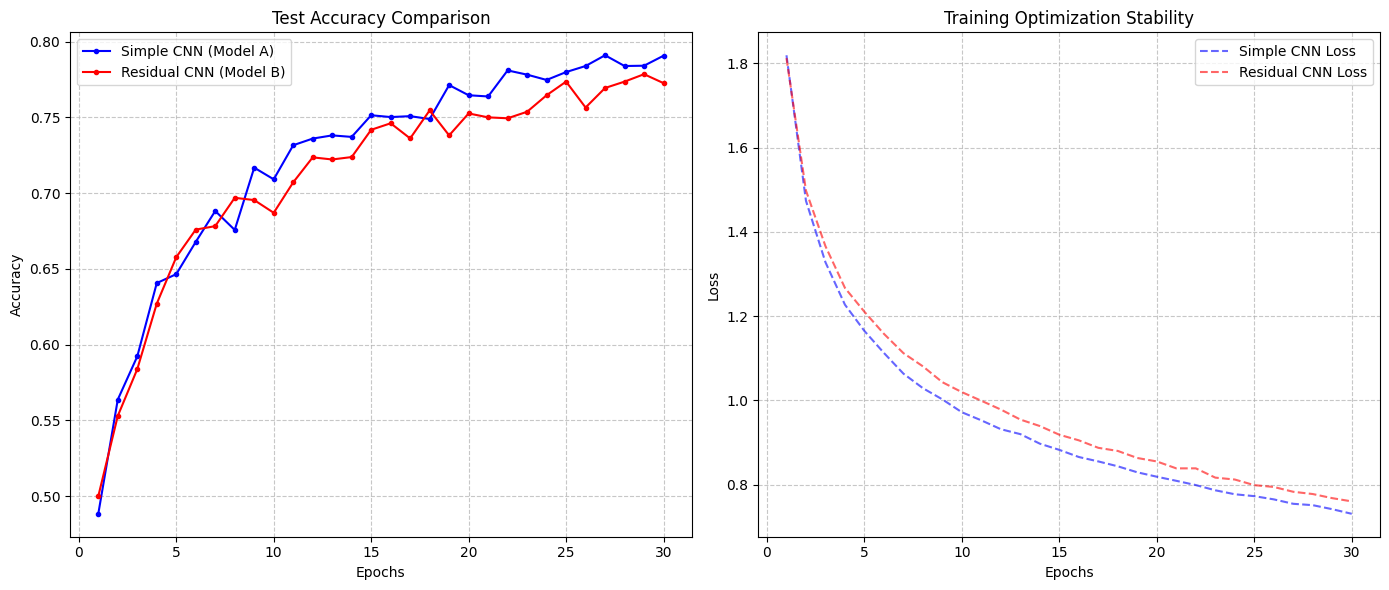

In [ ]:
# Task 2 Part b) Training curves overlay (A vs. B), final test accuracy

model2.eval()
correct = total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model2(images)
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

final_acc_residual = 100 * correct / total
print(f'Residual CNN Final Test Accuracy: {final_acc_residual:.2f}%')

epochs = range(1, len(history2['train_loss']) + 1)
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs, history1['test_acc'], 'b-', label='Simple CNN (Model A)', marker='.')
plt.plot(epochs, history2['test_acc'], 'r-', label='Residual CNN (Model B)', marker='.')
plt.title('Test Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history1['train_loss'], 'b--', label='Simple CNN Loss', alpha=0.6)
plt.plot(epochs, history2['train_loss'], 'r--', label='Residual CNN Loss', alpha=0.6)
plt.title('Training Optimization Stability')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

Task 2 Part c) **Brief Analysis**

# Task 3) Self-Supervised Pretraining + Fine-tuning
Pretrain either your vanilla CNN or residual CNN without labels, then
fine-tune on labeled CIFAR-10, with the following specifications:
- Choose one SSL strategy from the below list:
  * Predictive: Rotation prediction (0/90/180/270) or patch jigsaw.
  * Contrastive: SimCLR-style instance discrimination (two strong
views).
  * Masked modeling / reconstruction: Mask random patches and
predict pixels/features.
- Follow the below training protocol:
  * Pretrain on the entire unlabeled CIFAR-10 train set (labels
hidden).
  * Evaluation B (Fine-tune): Unfreeze and fine-tune end-to-end
with 10% labeled data (make sure to sample uniformly across
classes!).

## Description of Approach
a

In [12]:
class SimCLRTransform:
    def __init__(self, transform):
        self.transform = transform

    def __call__(self, x):
        return self.transform(x), self.transform(x)

class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.5):
        super().__init__()
        self.temperature = temperature

    def forward(self, z_i, z_j):
        batch_size = z_i.shape[0]

        features = torch.cat([z_i, z_j], dim=0)

        features = F.normalize(features, dim=1)
        similarity_matrix = torch.matmul(features, features.T)

        labels = torch.cat([
            torch.arange(batch_size) + batch_size,
            torch.arange(batch_size)
        ], dim=0).to(features.device)

        mask = torch.eye(labels.shape[0], dtype=torch.bool).to(features.device)
        similarity_matrix.masked_fill_(mask, -9e15)

        logits = similarity_matrix / self.temperature
        loss = F.cross_entropy(logits, labels)
        return loss

def get_balanced_10_percent_subset(dataset, num_classes=10):
    indices = []
    targets = np.array(dataset.targets)
    for c in range(num_classes):
        class_indices = np.where(targets == c)[0]
        n_samples = int(len(class_indices) * 0.10)
        selected = np.random.choice(class_indices, n_samples, replace=False)
        indices.extend(selected)

    return Subset(dataset, indices)

In [13]:
simclr_transform = transforms.Compose([
    transforms.RandomResizedCrop(size=32, scale=(0.2, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([
        transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)
    ], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2023, 0.1994, 0.2010]
    )
])
simclr_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    transform=SimCLRTransform(simclr_transform),
    download=True
)
simclr_loader = torch.utils.data.DataLoader(
    simclr_dataset,
    batch_size=96,
    shuffle=True,
    num_workers=2,
    drop_last=True
)

model_simclr = EncoderWrapper(
    encoder=SimpleCNNEncoder(), output_dim=64
).to(device)
opt_simclr = torch.optim.SGD(
    model_simclr.parameters(), lr=0.001, weight_decay=1e-4, momentum=0.9
)
criterion_simclr = NTXentLoss(temperature=0.5)

sub10_dataset = get_balanced_10_percent_subset(train_dataset)
sub10_loader = torch.utils.data.DataLoader(
    sub10_dataset, batch_size=96, shuffle=True, num_workers=2
)

In [14]:
print("--- SimCLR Pretraining ---")
for epoch in range(15):
    model_simclr.train()
    total_loss = 0
    for (img1, img2), _ in simclr_loader:
        img1 = img1.to(device)
        img2 = img2.to(device)

        opt_simclr.zero_grad()

        z1 = model_simclr(img1)
        z2 = model_simclr(img2)

        loss = criterion_simclr(z1, z2)

        loss.backward()
        opt_simclr.step()

        total_loss += loss.item()

    print(f"SimCLR Epoch {epoch+1}: Loss {total_loss / len(simclr_loader):.4f}")

model3 = EncoderWrapper(encoder=model_simclr.encoder, output_dim=10).to(device)
criterion3 = nn.CrossEntropyLoss()

for param in model3.encoder.parameters():
    param.requires_grad = False

print("\n--- Step A: Linear Probing (Head Only) ---")
opt3_head = torch.optim.SGD(model3.head.parameters(), lr=0.001, momentum=0.9)
for epoch in range(5):
    model3.train()
    for images, labels in sub10_loader:
        images = images.to(device)
        labels= labels.to(device)

        opt3_head.zero_grad()
        logits = model3(images)

        loss = criterion3(logits, labels)
        loss.backward()

        opt3_head.step()

    print(f"Warmup Epoch {epoch+1} Done")

print("\n--- Evaluation B: Fine-Tuning (Unfrozen) ---")
for param in model3.encoder.parameters():
    param.requires_grad = True

opt3_full = torch.optim.SGD(model3.parameters(), lr=0.001, momentum=0.9)
history3 = train_model(model3, criterion3, opt3_full, sub10_loader)

--- SimCLR Pretraining ---
SimCLR Epoch 1: Loss 4.5294
SimCLR Epoch 2: Loss 4.3379
SimCLR Epoch 3: Loss 4.2741
SimCLR Epoch 4: Loss 4.2290
SimCLR Epoch 5: Loss 4.1953
SimCLR Epoch 6: Loss 4.1704
SimCLR Epoch 7: Loss 4.1468
SimCLR Epoch 8: Loss 4.1320
SimCLR Epoch 9: Loss 4.1207
SimCLR Epoch 10: Loss 4.1092
SimCLR Epoch 11: Loss 4.1038
SimCLR Epoch 12: Loss 4.0970
SimCLR Epoch 13: Loss 4.0874
SimCLR Epoch 14: Loss 4.0814
SimCLR Epoch 15: Loss 4.0768

--- Step A: Linear Probing (Head Only) ---
Warmup Epoch 1 Done
Warmup Epoch 2 Done
Warmup Epoch 3 Done
Warmup Epoch 4 Done
Warmup Epoch 5 Done

--- Evaluation B: Fine-Tuning (Unfrozen) ---
ep0: tr_loss: 1.728, tr_acc: 0.367 | te_loss: 1.625, te_acc: 0.403
ep1: tr_loss: 1.623, tr_acc: 0.411 | te_loss: 1.528, te_acc: 0.441
ep2: tr_loss: 1.570, tr_acc: 0.435 | te_loss: 1.449, te_acc: 0.471
ep3: tr_loss: 1.505, tr_acc: 0.451 | te_loss: 1.387, te_acc: 0.488
ep4: tr_loss: 1.480, tr_acc: 0.458 | te_loss: 1.415, te_acc: 0.498
ep5: tr_loss: 1.466, t